<a href="https://colab.research.google.com/github/felipe-lim4/analise-exploratoria-alugueis/blob/main/analise_exploratoria_alugueis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise exploratória - Pandas - Aluguéis de imóveis do Rio de Janeiro

In [3]:
import pandas as pd

In [55]:
url = "https://raw.githubusercontent.com/alura-cursos/pandas-conhecendo-a-biblioteca/main/base-de-dados/aluguel.csv"
csv = pd.read_csv(url, sep=';' ) # dados separados por ';' e não por ','.
csv.head()

,Tipo,Bairro,Quartos,Vagas,Suites,Area,Valor,Condominio,IPTU
0,Quitinete,Copacabana,1,0,0,40,1700.0,500.0,60.0
1,Casa,Jardim Botânico,2,0,1,100,7000.0,NaN,NaN
2,Conjunto Comercial/Sala,Barra da Tijuca,0,4,0,150,5200.0,4020.0,1111.0
3,Apartamento,Centro,1,0,0,15,800.0,390.0,20.0
4,Apartamento,Higienópolis,1,0,0,48,800.0,230.0,NaN


In [57]:
csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32960 entries, 0 to 32959
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Tipo        32960 non-null  object 
 1   Bairro      32960 non-null  object 
 2   Quartos     32960 non-null  int64  
 3   Vagas       32960 non-null  int64  
 4   Suites      32960 non-null  int64  
 5   Area        32960 non-null  int64  
 6   Valor       32943 non-null  float64
 7   Condominio  28867 non-null  float64
 8   IPTU        22723 non-null  float64
dtypes: float64(3), int64(4), object(2)
memory usage: 2.3+ MB


Com o comando .info() do pandasjá possivel notar que grande parte dos dados são numericos, no entanto eles estão irregulares, com a quantidade de linhas menor entre si.

In [66]:
csv.shape #mostra a quantidade de linhas e colunas respectivamente.
# Nisso da para ver claramente que as colunas de Valor do imovel, Condominio e IPTU possuem menos linhas que o maximo do dataframe.

(32960, 9)

Para tratar os dados, é bem melhor que os nomes das colunas não possuam acentuação e estejam todos em lowercase

Além disso, também é possivel observar que dados do tipo object deveriam ser do tipo srt

In [67]:
df = csv.copy()
df.columns = [name.lower() for name in csv.columns.values]
df.head()

,quartos,vagas,suites,area,valor,condominio,iptu
count,32960.000000,32960.000000,32960.000000,32960.000000,3.294300e+04,2.886700e+04,2.272300e+04
mean,1.771390,1.749059,0.665777,231.901547,1.295266e+04,2.388062e+03,2.364410e+03
std,1.717869,20.380402,1.176525,1135.254152,6.675220e+05,3.918496e+04,1.795641e+05
min,0.000000,0.000000,0.000000,0.000000,7.500000e+01,1.000000e+00,1.000000e+00
25%,0.000000,0.000000,0.000000,55.000000,1.500000e+03,5.900000e+02,1.100000e+02
50%,2.000000,1.000000,0.000000,87.000000,2.800000e+03,9.900000e+02,2.500000e+02
75%,3.000000,2.000000,1.000000,170.000000,6.500000e+03,1.800000e+03,6.970000e+02
max,100.000000,1966.000000,70.000000,90000.000000,1.200000e+08,6.552570e+06,2.705307e+07


In [69]:
df.describe() #Observe um detalhe interessante, que apartamento é esse que tem 100 quartos? Ou pior 1966 vagas?

,quartos,vagas,suites,area,valor,condominio,iptu
count,32960.000000,32960.000000,32960.000000,32960.000000,3.294300e+04,2.886700e+04,2.272300e+04
mean,1.771390,1.749059,0.665777,231.901547,1.295266e+04,2.388062e+03,2.364410e+03
std,1.717869,20.380402,1.176525,1135.254152,6.675220e+05,3.918496e+04,1.795641e+05
min,0.000000,0.000000,0.000000,0.000000,7.500000e+01,1.000000e+00,1.000000e+00
25%,0.000000,0.000000,0.000000,55.000000,1.500000e+03,5.900000e+02,1.100000e+02
50%,2.000000,1.000000,0.000000,87.000000,2.800000e+03,9.900000e+02,2.500000e+02
75%,3.000000,2.000000,1.000000,170.000000,6.500000e+03,1.800000e+03,6.970000e+02
max,100.000000,1966.000000,70.000000,90000.000000,1.200000e+08,6.552570e+06,2.705307e+07


In [111]:
import matplotlib.pyplot as plt

In [128]:
media_geral = df['valor'].mean()
df_valor_medio_tipo = df[['tipo', 'valor']].groupby('tipo').mean().sort_values('valor')
df_valor_medio_tipo

,valor
tipo,
Quitinete,1246.840909
Pousada/Chalé,1480.000000
Casa de Vila,1574.369478
Box/Garagem,1899.756098
Studio,2400.000000
Loft,2557.882353
Flat,4546.189076
Apartamento,4744.614648
Chácara,4900.000000


<Axes: ylabel='tipo'>

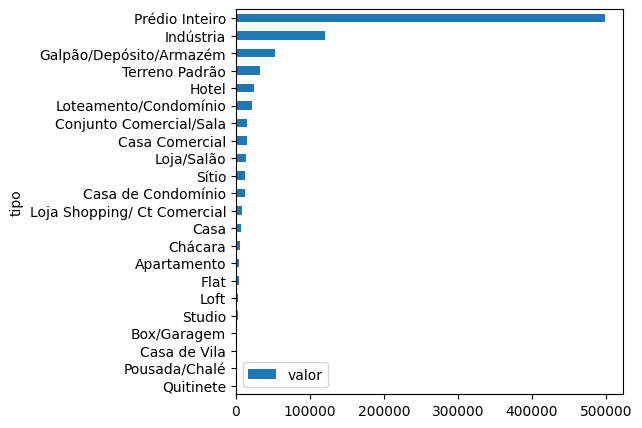

In [130]:
df_preco_tipo = df[['tipo', 'valor']].groupby('tipo').mean().sort_values('valor')
df_preco_tipo.plot(kind='barh', figsize=(5,5))

Agora é possivel identificar de forma mais clara porque havia "casas" com 100 quartos. Aqui a base de dados abrange todos os tipos de imoveis, os comerciais e os residenciais.

In [139]:
valor_imoveis_bairro_apartamento = df.groupby(['bairro', 'tipo'])[['valor']].mean(numeric_only=True)


Bem interessante mostrar que o valor entre os próprios tipos de imóveis variam de preço de acordo com o bairro, então talvez em um futuro treinamento de modelo de regressão seja necessario filtrar e fazer modelos especificos para bairros que possuem maior semelhança de preço e não variam tanto de resultado.

<Axes: xlabel='tipo'>

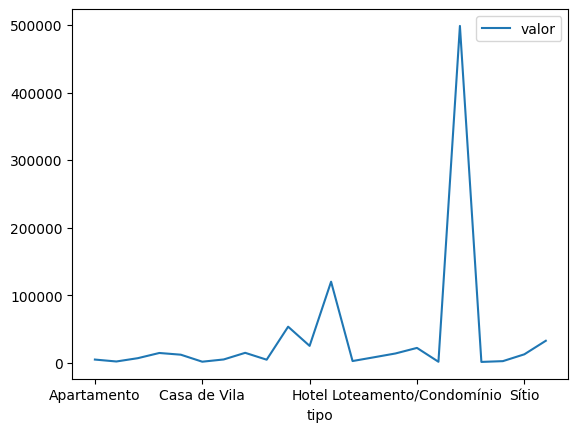

In [143]:
valor_imoveis_por_tipo = df.groupby('tipo')[['valor']].mean()
valor_imoveis_por_tipo.plot(kind='line')

##### Defina um foco!
Como a ideia é poder analisar o preço dos imoveis RESIDENCIAIS, faz bastante sentido remover as colunas de imoveis comerciais, deixando nossa base mais homogenea e linear, possibilitanto o treinamento futuro de um modelo.

In [159]:
list(df.tipo.unique())
imoveis_para_retirada = ['Conjunto Comercial/Sala',

                      'Prédio Inteiro', 'Loja/Salão',

                      'Galpão/Depósito/Armazém',

                      'Casa Comercial', 'Terreno Padrão',

                      'Loja Shopping/ Ct Comercial',

                      'Box/Garagem', 'Chácara',

                      'Loteamento/Condomínio', 'Sítio',

                      'Pousada/Chalé', 'Hotel', 'Indústria']

<Axes: ylabel='tipo'>

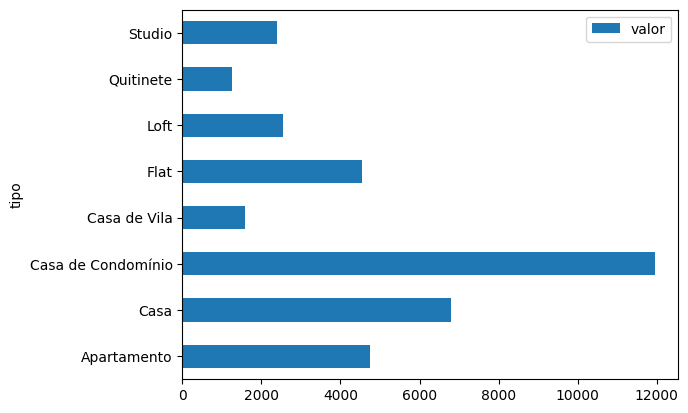

In [174]:
df_filtrados = df.query('@imoveis_para_retirada not in tipo')
dados_agrupados_tipo = df_filtrados.groupby('tipo')[['valor']].mean()
dados_agrupados_tipo.plot(kind='barh')

Com o foco definido, fica nitido que a variação dos dados diminui significativamente.

AttributeError: 'DataFrameGroupBy' object has no attribute 'sum_values'